# Machine Learning Foundations: Polynomial Regression & Feature Engineering

**Summary**
This notebook demonstrates how to adapt linear regression to model complex, non-linear relationships by creating derivative polynomial features, allowing the model to fit curves instead of just straight lines.

**Key Takeaways:**

1.  **Feature Engineering**: Creating new features by raising existing ones to a power (e.g., $x, x^2, x^3, \dots, x^n$) to capture non-linear patterns in the data.
2.  **Polynomial Fit**: Using the linear regression framework to solve non-linear problems (like fitting a cosine curve) by transforming the input space.
3.  **Critical Scaling**: Understanding that higher-order polynomials create extreme differences in feature ranges (e.g., $20^1$ vs $20^{13}$), making **Z-score normalization** mandatory for convergence.
4.  **Model Complexity**: Experimenting with high-degree polynomials (up to the 13th power) and observing how the model adjusts its weights to approximate complex functions.
5.  **Reusability**: Leveraging core functions (`compute_cost`, `compute_gradient`, `gradient_descent`) developed in previous notebooks to solve a fundamentally different type of problem.

---


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
np.set_printoptions(precision=2)

Using code from previous notebooks...


In [ ]:
def zscore_normalize_features(X):
    """
    computes  X, zcore normalized by column

    Args:
      X (ndarray (m,n))     : input data, m examples, n features

    Returns:
      X_norm (ndarray (m,n)): input normalized by column
      mu (ndarray (n,))     : mean of each feature
      sigma (ndarray (n,))  : standard deviation of each feature
    """
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma  # NOSONAR

    return (X_norm, mu, sigma)


def predict_one_value_with_normalization(x, w, b, X_mean, X_std):  # NOSONAR
    """
    Computes the prediction of linear model

    Args:
        x (ndarray): Input values
        w (ndarray): Weights
        b (float): Bias
        X_mean (ndarray): Mean of features
        X_std (ndarray): Standard deviation of features
    Returns:
        float: Prediction
    """
    x = (x - X_mean) / X_std
    return np.dot(x, w) + b


def predict_one_value_without_normalization(x, w, b):
    """
    Computes the prediction of linear model

    Args:
        x (ndarray): Input values
        w (ndarray): Weights
        b (float): Bias
    Returns:
        float: Prediction
    """
    return np.dot(x, w) + b


def compute_cost(X, y, w, b):
    """Computes the cost over all examples
    Args:
      x (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters
      b (scalar)       : model parameter
    Returns
      cost (scalar): cost
    """

    m, n = X.shape
    cost = 0.0
    for i in range(m):
        f_wb = predict_one_value_without_normalization(X[i], w, b)
        cost = cost + (f_wb - y[i]) ** 2

    cost = cost / (2 * m)
    return cost


def compute_gradient(X, y, w, b):
    """Computes the gradient for linear regression with multiple variables
    Args:
      X (ndarray (m,n)): Data, m examples
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters
      b (scalar): model parameter
    Returns
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b
    """

    m, n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        f_wb = predict_one_value_without_normalization(X[i], w, b)
        error = f_wb - y[i]
        for j in range(n):
            dj_dw[j] += error * X[i, j]
        dj_db += error

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db


def gradient_descent(X, y, w_initial, b_initial, learning_rate, num_iterations, cost_function, gradient_function):
    """
    Performs gradient descent to optimize the parameters of a linear regression model.

    Args:
        X (ndarray): Input features
        y (ndarray): Target values
        w_initial (ndarray): Initial weights
        b_initial (float): Initial bias
        learning_rate (float): Learning rate
        num_iterations (int): Number of iterations
        cost_function (function): Cost function
        gradient_function (function): Gradient function

    Returns:
        tuple: Optimized weights, optimized bias, cost history, parameter history
    """

    w = w_initial
    b = b_initial

    # Number of training examples
    m, n = X.shape

    cost_history = []
    param_history = []

    for i in range(num_iterations):
        # Computing gradient
        dj_dw, dj_db = gradient_function(X, y, w, b)

        # Updating parameters
        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db

        # Computing cost
        cost = cost_function(X, y, w, b)

        # Storing history
        cost_history.append(cost)
        param_history.append((w, b))

        # Printing cost every 50 iterations
        if i % 100000 == 0:
            print(f"Iteration {i:4}: Cost = {cost:0.2e}")

    return w, b, cost_history, param_history

Polynomial Regression to fit a curve to the data instead of a line


In [ ]:
x = np.arange(0, 20, 1)
y = np.cos(x/2)

X = np.c_[x, x**2, x**3, x**4, x**5, x**6, x **
          7, x**8, x**9, x**10, x**11, x**12, x**13]
# Normalizing the data
X, mu, sigma = zscore_normalize_features(X)

In [34]:
# Initializing parameters
w_initial = np.zeros((X.shape[1],))
b_initial = 0.0

learning_rate = 1e-1
num_iterations = 1000000

w_final, b_final, cost_history, param_history = gradient_descent(
    X, y, w_initial, b_initial, learning_rate, num_iterations, compute_cost, compute_gradient)

print(f"b,w found by gradient descent: {b_final:0.2f}, {w_final} ")

Iteration    0: Cost = 2.20e-01
Iteration 100000: Cost = 1.70e-02
Iteration 200000: Cost = 1.28e-02
Iteration 300000: Cost = 9.73e-03
Iteration 400000: Cost = 7.56e-03
Iteration 500000: Cost = 6.01e-03
Iteration 600000: Cost = 4.90e-03
Iteration 700000: Cost = 4.10e-03
Iteration 800000: Cost = 3.53e-03
Iteration 900000: Cost = 3.11e-03
b,w found by gradient descent: -0.01, [ -1.34 -10.    24.78   5.96 -12.49 -16.26  -9.51   0.59   8.7   11.94
   9.27   0.79 -12.82] 


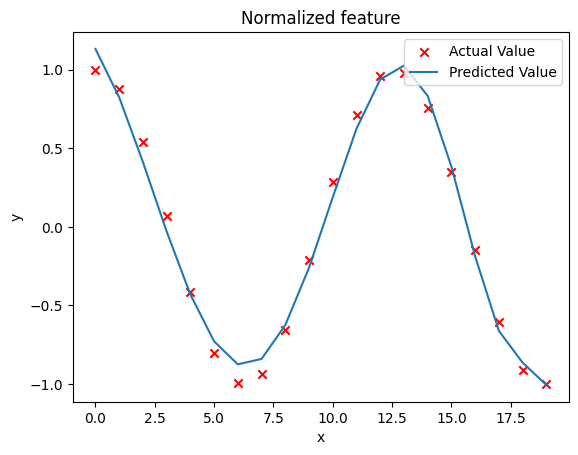

In [ ]:
plt.scatter(x, y, marker='x', c='r', label="Actual Value")
plt.title("Normalized feature")
plt.plot(x, X@w_final + b_final, label="Predicted Value")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()